In [8]:
from datetime import datetime
import matplotlib.pyplot as plt

In [7]:
selected_dates_kuehtai_22_23 = [
    datetime(2022, 10, 3), datetime(2022, 10, 28), datetime(2023, 3, 22),
    datetime(2023, 6, 7), datetime(2023, 6, 20), datetime(2023, 6, 25),
    datetime(2023, 7, 15), datetime(2023, 8, 11)
]

selected_dates_kuehtai_23_24 = [
    datetime(2023, 10, 13), datetime(2023, 10, 28), datetime(2024, 2, 5),
    datetime(2024, 3, 11), datetime(2024, 4, 12), datetime(2024, 5, 20),
    datetime(2024, 6, 19), datetime(2024, 6, 29), datetime(2024, 7, 9),
    datetime(2024, 7, 14), datetime(2024, 8, 10)
]

selected_dates_kaunertal_22_23 = [
    datetime(2022, 10, 3), datetime(2022, 10, 28), datetime(2023, 3, 22),
    datetime(2023, 5, 3), datetime(2023, 6, 7), datetime(2023, 6, 25),
    datetime(2023, 7, 15), datetime(2023, 8, 11)
]

selected_dates_kaunertal_23_24 = [
    datetime(2023, 10, 25), datetime(2023, 10, 28), datetime(2024, 2, 5),
    datetime(2024, 3, 11), datetime(2024, 4, 12), datetime(2024, 5, 20),
    datetime(2024, 6, 19), datetime(2024, 6, 29), datetime(2024, 7, 9),
    datetime(2024, 7, 14), datetime(2024, 8, 10)
]

selected_dates_achensee_22_23 = [
    datetime(2022, 11, 9), datetime(2022, 11, 27), datetime(2023, 1, 1),
    datetime(2023, 2, 10), datetime(2023, 2, 15), datetime(2023, 2, 22),
    datetime(2023, 3, 7), datetime(2023, 3, 22), datetime(2023, 4, 21)
]

selected_dates_achensee_23_24 = [
    datetime(2023, 11, 4), datetime(2023, 12, 27), datetime(2024, 1, 3),
    datetime(2024, 2, 15), datetime(2024, 3, 8), datetime(2024, 4, 7),
    datetime(2024, 4, 27), datetime(2024, 4, 30)
]

In [17]:
# Data for 2022–23
dates_22_23 = {
    'Kühtai': (selected_dates_kuehtai_22_23, 'black', 'o'),
    'Kaunertal': (selected_dates_kaunertal_22_23, 'black', 'o'),
    'Achensee': (selected_dates_achensee_22_23, 'black', 'o')
}

# Data for 2023–24
dates_23_24 = {
    'Kühtai': (selected_dates_kuehtai_23_24, 'black', 'o'),
    'Kaunertal': (selected_dates_kaunertal_23_24, 'black', 'o'),
    'Achensee': (selected_dates_achensee_23_24, 'black', 'o')
}

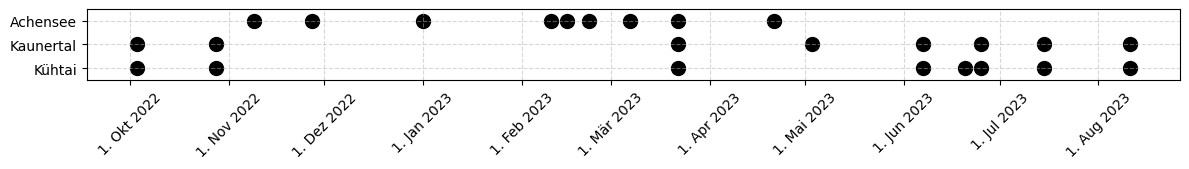

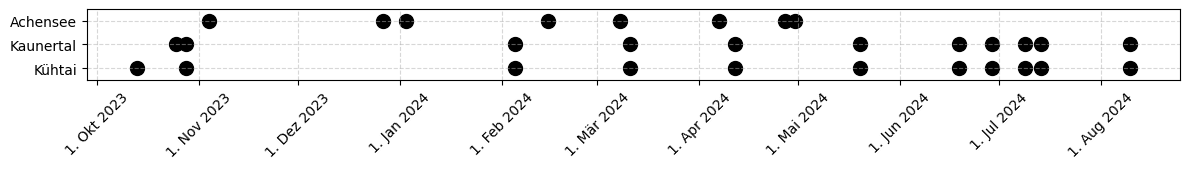

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# German month names (abbreviated)
german_months = {
    1: "Jan", 2: "Feb", 3: "Mär", 4: "Apr", 5: "Mai", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sep", 10: "Okt", 11: "Nov", 12: "Dez"
}

# Helper: Get 1st of each month
def get_month_start_ticks(dates):
    start = min(dates)
    end = max(dates)
    current = datetime(start.year, start.month, 1)
    ticks = []
    while current <= end:
        ticks.append(current)
        if current.month == 12:
            current = datetime(current.year + 1, 1, 1)
        else:
            current = datetime(current.year, current.month + 1, 1)
    return ticks

# Updated plotting function
def plot_season(dates_dict, title):
    plt.figure(figsize=(12, 1.8))  # Was 4, now ~1.8
    y_positions = {'Kühtai': 0.2, 'Kaunertal': 0.4, 'Achensee': 0.6}

    # Combine all dates to compute tick range
    all_dates = []
    for dates, _, _ in dates_dict.values():
        all_dates.extend(dates)

    # Plot points
    for location, (dates, color, marker) in dates_dict.items():
        plt.scatter(dates, [y_positions[location]] * len(dates),
                    color=color, marker=marker, s=100, label=location)

    # Create and format x-axis ticks
    month_starts = get_month_start_ticks(all_dates)
    tick_labels = [f"1. {german_months[dt.month]} {dt.year}" for dt in month_starts]
    plt.xticks(month_starts, tick_labels, rotation=45)

    plt.yticks([0.2, 0.4, 0.6], ['Kühtai', 'Kaunertal', 'Achensee'])
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.ylim(0.1, 0.7)  # Adjust to fit your final spacing

    plt.tight_layout()
    plt.show()

# Now run the plots again
plot_season(dates_22_23, 'Zeitleiste der ausgewählten Daten (Saison 2022–23)')
plot_season(dates_23_24, 'Zeitleiste der ausgewählten Daten (Saison 2023–24)')


In [64]:
import matplotlib.pyplot as plt
from datetime import datetime

# German month names
german_months = {
    1: "Jan", 2: "Feb", 3: "Mär", 4: "Apr", 5: "Mai", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sep", 10: "Okt", 11: "Nov", 12: "Dez"
}

# Map dates to dummy year for seasonal alignment
def map_to_dummy_year(dates):
    return [datetime(2000 if d.month >= 10 else 2001, d.month, d.day) for d in dates]

# Ticks for x-axis: 1st of each month in seasonal order (Oct to Aug)
def get_season_ticks():
    months = [10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8]
    return [datetime(2000 if m >= 10 else 2001, m, 1) for m in months]

def plot_seasons_stacked(season1, season2):
    fig, axs = plt.subplots(2, 1, figsize=(12, 4), sharex=True)

    # Change order here:
    y_positions = {'Kaunertal': 0.2, 'Kühtai': 0.4, 'Achensee': 0.6}

    # Season 1 (top)
    ax = axs[0]
    for location in ['Achensee', 'Kühtai', 'Kaunertal']:
        dates, color, marker = season1[location]
        aligned = map_to_dummy_year(dates)
        ax.scatter(aligned, [y_positions[location]] * len(dates),
                   color=color, marker=marker, s=100, label=location)
    ax.set_yticks(list(y_positions.values()))
    ax.set_yticklabels(list(y_positions.keys()))
    ax.set_ylim(0.1, 0.7)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_title("Saison 2022–23", fontsize=13)

    # Season 2 (bottom)
    ax = axs[1]
    for location in ['Achensee', 'Kühtai', 'Kaunertal']:
        dates, color, marker = season2[location]
        aligned = map_to_dummy_year(dates)
        ax.scatter(aligned, [y_positions[location]] * len(dates),
                   color=color, marker=marker, s=100, label=location)
    ax.set_yticks(list(y_positions.values()))
    ax.set_yticklabels(list(y_positions.keys()))
    ax.set_ylim(0.1, 0.7)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_title("Saison 2023–24", fontsize=13)

    # Shared x-axis formatting on bottom plot
    ticks = get_season_ticks()
    labels = [f"1. {german_months[d.month]}" for d in ticks]
    axs[1].set_xticks(ticks)
    axs[1].set_xticklabels(labels, rotation=45)

    plt.tight_layout()
    plt.savefig(r'C:\Users\Moritz\Documents\Uni\Masterarbeit\Abbildungen\110fscTimeline.png', dpi=300)
    plt.show()


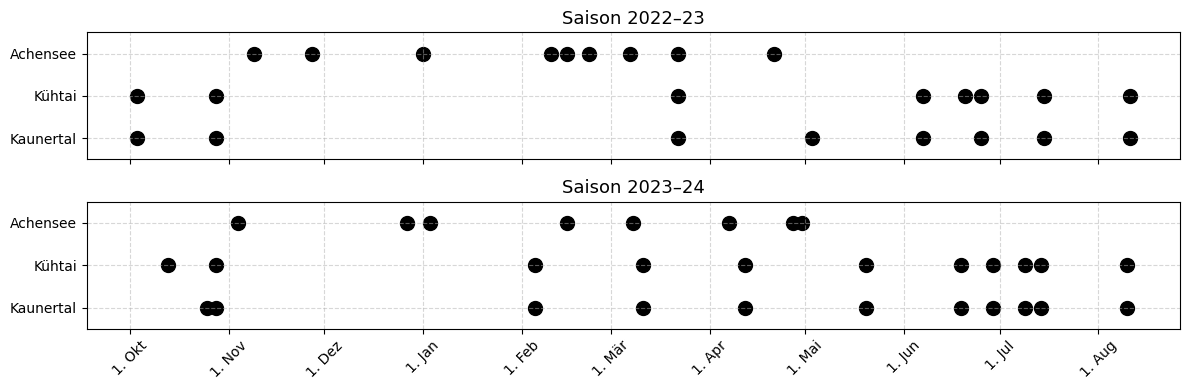

In [65]:
# Plot it
plot_seasons_stacked(dates_22_23, dates_23_24)
